In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from tqdm import tqdm

/home/nexpg/anaconda3/envs/my314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Загрузка данных и подготовка тестовой выборки

df = pd.read_csv('rnc_dataset_markup_with_split.csv')
df['targetDetectedMcIds'] = df['targetDetectedMcIds'].apply(ast.literal_eval)
df['targetSplitMcIds'] = df['targetSplitMcIds'].apply(ast.literal_eval)

# Отбираем только тестовые строки
df_test = df[df['split'] == 'test'].reset_index(drop=True)
print(f"Размер тестовой выборки: {len(df_test)}")


Размер тестовой выборки: 496


In [3]:
# 2. Восстановление словаря меток (такого же, как при обучении)

all_mc_ids = sorted(set([mc for mcs in df['targetDetectedMcIds'] for mc in mcs]))
id2idx = {mc_id: i for i, mc_id in enumerate(all_mc_ids)}
idx2id = {i: mc_id for mc_id, i in id2idx.items()}
num_labels = len(all_mc_ids)
print(f"Всего уникальных микрокатегорий: {num_labels}")

Всего уникальных микрокатегорий: 10


In [4]:
# ## 3. Загрузка моделей и токенизатора
# Используем те же параметры, что и при обучении:
# - Порог для detected модели: 0.45
# - Порог для split модели: 0.25

tokenizer = AutoTokenizer.from_pretrained("deepvk/USER2-base")

detected_model = AutoModelForSequenceClassification.from_pretrained(
    "./final_detected_model",
    device_map="auto"
)
detected_model.eval()

split_model = AutoModelForSequenceClassification.from_pretrained(
    "./final_split_model",
    device_map="auto"
)
split_model.eval()

# Пороги оставляем как были
DETECTED_THRESHOLD = 0.45
SPLIT_THRESHOLD = 0.25

Loading weights: 100%|██████████| 138/138 [00:00<00:00, 322.14it/s]


In [5]:
# 4. Функции для предсказаний

def predict_labels(model, texts, threshold, batch_size=16):
    predictions = []
    
    device = next(model.parameters()).device
    
    # Прогресс-бар по батчам
    for i in tqdm(range(0, len(texts), batch_size), desc="Инференс", unit="batch"):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(batch_texts, truncation=True, max_length=1024, padding=True, return_tensors="pt")
        
        encodings = {k: v.to(device) for k, v in encodings.items()}
        
        with torch.no_grad():
            logits = model(**encodings).logits
            probs = torch.sigmoid(logits).cpu().numpy()
        for prob in probs:
            pred_ids = [idx2id[i] for i, p in enumerate(prob) if p > threshold]
            predictions.append(pred_ids)
    return predictions

In [6]:
# 5. Прогон тестовой выборки через пайплайн

test_texts_detected = [f"classification: {row['cleaned_description']}" for _, row in df_test.iterrows()]

print("Предсказания detected модели...")
pred_detected = predict_labels(detected_model, test_texts_detected, DETECTED_THRESHOLD, batch_size=16)

# → ВАЖНО: текст для split модели строится на основе ПРЕДСКАЗАННЫХ detected категорий
test_texts_split = []
for idx, row in df_test.iterrows():
    pred_mc_list = pred_detected[idx]
    detected_str = ", ".join(map(str, pred_mc_list)) if pred_mc_list else "none"
    text_split = f"categories: {detected_str} [SEP] {row['cleaned_description']}"
    test_texts_split.append(text_split)

print("Предсказания split модели...")
pred_split = predict_labels(split_model, test_texts_split, SPLIT_THRESHOLD, batch_size=16)

Предсказания detected модели...


Инференс: 100%|██████████| 31/31 [00:40<00:00,  1.32s/batch]


Предсказания split модели...


Инференс: 100%|██████████| 31/31 [00:40<00:00,  1.32s/batch]


In [7]:
# ## 6. Расчёт метрик
# Истинные метки:
# - `true_detected` — список списков `targetDetectedMcIds`
# - `true_split` — список списков `targetSplitMcIds`
# Для micro-метрик нужно развернуть все предсказания в плоские векторы.

true_detected = df_test['targetDetectedMcIds'].tolist()
true_split = df_test['targetSplitMcIds'].tolist()

# Функция для преобразования списка списков в плоский бинарный вектор (по всем меткам)
def multilabel_binarize(lists_of_ids, all_ids):
    """Возвращает матрицу размера (n_samples, n_labels) с 0/1."""
    n_samples = len(lists_of_ids)
    n_labels = len(all_ids)
    matrix = np.zeros((n_samples, n_labels), dtype=int)
    id_to_idx = {id_: i for i, id_ in enumerate(all_ids)}
    for i, ids in enumerate(lists_of_ids):
        for id_ in ids:
            if id_ in id_to_idx:
                matrix[i, id_to_idx[id_]] = 1
    return matrix

# Бинаризация
y_true_detected_mat = multilabel_binarize(true_detected, all_mc_ids)
y_pred_detected_mat = multilabel_binarize(pred_detected, all_mc_ids)

y_true_split_mat = multilabel_binarize(true_split, all_mc_ids)
y_pred_split_mat = multilabel_binarize(pred_split, all_mc_ids)

# %%
# Метрики для detected модели
def micro_metrics(y_true_mat, y_pred_mat):
    tp = np.sum((y_true_mat == 1) & (y_pred_mat == 1))
    fp = np.sum((y_true_mat == 0) & (y_pred_mat == 1))
    fn = np.sum((y_true_mat == 1) & (y_pred_mat == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

det_prec, det_rec, det_f1 = micro_metrics(y_true_detected_mat, y_pred_detected_mat)
print("=== DETECTED модель (multi-label) ===")
print(f"Micro Precision: {det_prec:.4f}")
print(f"Micro Recall:    {det_rec:.4f}")
print(f"Micro F1-score:  {det_f1:.4f}")

# %%
# Метрики для split модели (multi-label)
split_prec, split_rec, split_f1 = micro_metrics(y_true_split_mat, y_pred_split_mat)
print("\n=== SPLIT модель (multi-label) ===")
print(f"Micro Precision: {split_prec:.4f}")
print(f"Micro Recall:    {split_rec:.4f}")
print(f"Micro F1-score:  {split_f1:.4f}")


=== DETECTED модель (multi-label) ===
Micro Precision: 0.9834
Micro Recall:    0.9780
Micro F1-score:  0.9807

=== SPLIT модель (multi-label) ===
Micro Precision: 0.5612
Micro Recall:    0.5094
Micro F1-score:  0.5341


In [8]:
# ## 7. Метрика `shouldSplit` (бинарная)
# `shouldSplit = 1`, если список `targetSplitMcIds` не пуст, иначе 0.

y_true_should = (df_test['targetSplitMcIds'].apply(len) > 0).astype(int)
y_pred_should = (np.array([len(lst) for lst in pred_split]) > 0).astype(int)

acc = accuracy_score(y_true_should, y_pred_should)
prec, rec, f1, _ = precision_recall_fscore_support(y_true_should, y_pred_should, average='binary')

print("\n=== Бинарная задача shouldSplit ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")



=== Бинарная задача shouldSplit ===
Accuracy:  0.7802
Precision: 0.4359
Recall:    0.5426
F1-score:  0.4834


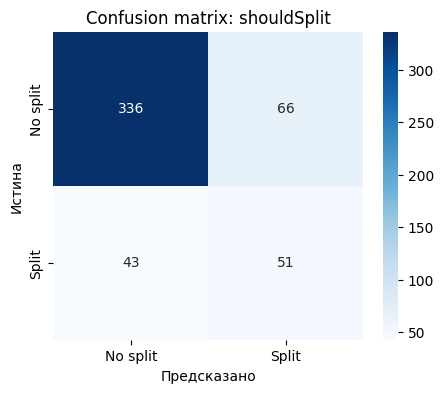

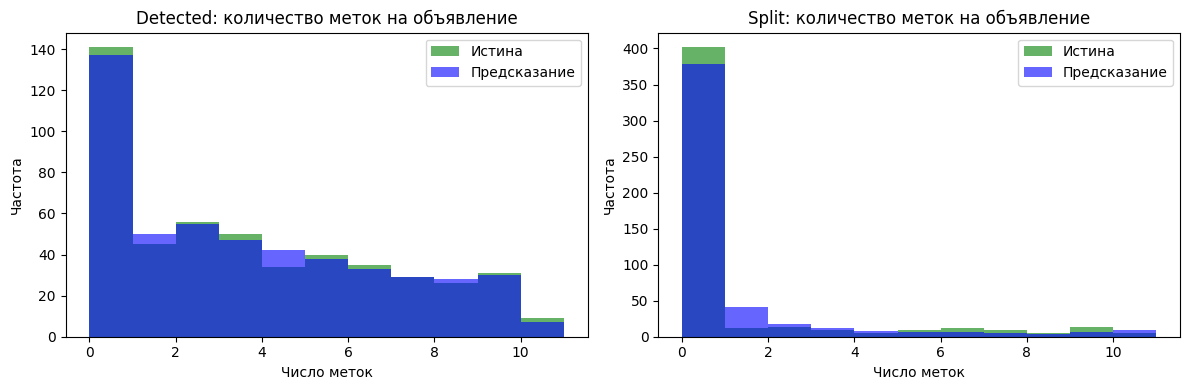

In [10]:
# 8. Визуализация результатов

# 8.1 Confusion matrix для shouldSplit
cm = confusion_matrix(y_true_should, y_pred_should)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No split', 'Split'], yticklabels=['No split', 'Split'])
plt.xlabel('Предсказано')
plt.ylabel('Истина')
plt.title('Confusion matrix: shouldSplit')
plt.show()

# 8.2 Распределение количества предсказанных меток (detected и split)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

len_pred_detected = [len(lst) for lst in pred_detected]
len_true_detected = [len(lst) for lst in true_detected]
axes[0].hist(len_true_detected, bins=range(0, max(len_true_detected)+2), alpha=0.6, label='Истина', color='green')
axes[0].hist(len_pred_detected, bins=range(0, max(len_pred_detected)+2), alpha=0.6, label='Предсказание', color='blue')
axes[0].set_title('Detected: количество меток на объявление')
axes[0].set_xlabel('Число меток')
axes[0].set_ylabel('Частота')
axes[0].legend()

len_pred_split = [len(lst) for lst in pred_split]
len_true_split = [len(lst) for lst in true_split]
axes[1].hist(len_true_split, bins=range(0, max(len_true_split)+2), alpha=0.6, label='Истина', color='green')
axes[1].hist(len_pred_split, bins=range(0, max(len_pred_split)+2), alpha=0.6, label='Предсказание', color='blue')
axes[1].set_title('Split: количество меток на объявление')
axes[1].set_xlabel('Число меток')
axes[1].set_ylabel('Частота')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# 9. Итоговая сводка

summary = pd.DataFrame({
    'Модель/задача': ['Detected (multi-label)', 'Split (multi-label)', 'ShouldSplit (binary)'],
    'Precision': [det_prec, split_prec, prec],
    'Recall':    [det_rec, split_rec, rec],
    'F1-score':  [det_f1, split_f1, f1],
    'Accuracy':  [np.nan, np.nan, acc]
})
print("\n=== ИТОГОВАЯ ТАБЛИЦА МЕТРИК ===")
print(summary.to_string(index=False))



=== ИТОГОВАЯ ТАБЛИЦА МЕТРИК ===
         Модель/задача  Precision   Recall  F1-score  Accuracy
Detected (multi-label)   0.983374 0.977955  0.980657       NaN
   Split (multi-label)   0.561201 0.509434  0.534066       NaN
  ShouldSplit (binary)   0.435897 0.542553  0.483412  0.780242
